# Charge corrections

When simulating a charged defect in a periodic system, we introduce unphysical long-range Coulomb interactions between the images. A correction method aims at obtaining the correct energies with already small supercell sizes in order to reduce the computational cost.

`defermi` currently supports two corrections methods: 
- [FNV (Freysoldt)](#freysoldt)
- [eFNV (Kumagai)](#kumagai)

## Freysoldt

DOI: https://doi.org/10.1002/pssb.201046289

The Freysoldt (FNV) approach expresses electrostatic interactions in terms of the unscreened charge density and the electrostatic potential. The defect potential is expressed as a sum of a long-range and a short-range part. The long-range  contribution is associated to macroscopic screening, which is set to decay as 1/εr. The long-range electrostatic energy correction is thus determined by the summation of the Fourier transform of the long-range potential in real space over the  reciprocal lattice vectors. Quantum effects are accounted for in the short-range  part associated to microscopic screening. This is obtained by subtracting the  long-range part to the electrostatic potential difference between defect and pure  structures, obtained from the DFT calculations.

Currently only `VASP` output files are supported. Use the `get_freysoldt_correction_from_locpot` function to compute the correction and generate the plots. This function is a wrapper for the `get_freysoldt_correction` function in the `pymatgen-analysis-defects` library. 

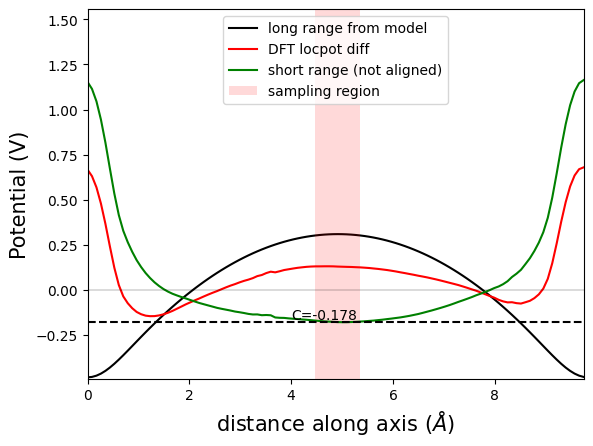

In [2]:
from defermi.corrections.freysoldt import get_freysoldt_correction_from_locpot

defect_path_locpot = '../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_O/q2/1-PBE-SCF/LOCPOT'
bulk_path_locpot = '../defermi/tests/test_files/SiO2-defects/Bulk-2x2x2-supercell/LOCPOT'

corr, ax = get_freysoldt_correction_from_locpot(
                                        charge=2,
                                        dielectric_constant=3.9,
                                        defect_path_locpot=defect_path_locpot,
                                        bulk_path_locpot=bulk_path_locpot,
                                        get_plot=True)

If `get_correction_data=True`, `pymatgen`'s `CorrectionResult` object is returned, which contains addition information regarding the potentials. Set `get_correction_data=False` to return only the final correction `float`.

In [3]:
corr

CorrectionResult(correction_energy=np.float64(1.7725067354055881), metadata={'plot_data': {0: {'pot_plot_data': {'Vr': [np.float64(-0.48678911089369287), np.float64(-0.4844166943764408), np.float64(-0.4774076358612981), np.float64(-0.4660735203843385), np.float64(-0.4508929267087604), np.float64(-0.43245860748372617), np.float64(-0.4114178154382888), np.float64(-0.38841552683784814), np.float64(-0.3640483340118092), np.float64(-0.3388334533176788), np.float64(-0.31319368944445025), np.float64(-0.28745624542078235), np.float64(-0.2618615124300531), np.float64(-0.2365774965479303), np.float64(-0.21171606352061592), np.float64(-0.18734825982317685), np.float64(-0.1635171638718689), np.float64(-0.14024773122376746), np.float64(-0.117553782380266), np.float64(-0.09544263786510716), np.float64(-0.07391800789731513), np.float64(-0.052981692363234766), np.float64(-0.03263452726110928), np.float64(-0.012876884458928891), np.float64(0.006291077594532344), np.float64(0.024869294216772142), np.flo

In [ ]:
get_freysoldt_correction_from_locpot(
                                charge=2,
                                dielectric_constant=3.9,
                                defect_path_locpot=defect_path_locpot,
                                bulk_path_locpot=bulk_path_locpot,
                                get_plot=False,
                                get_correction_data=False)

np.float64(1.7725067354055881)

## Kumagai

DOI: https://doi.org/10.1103/PhysRevB.89.195205

Kumagai et al have extended the FNV approach (eFNV scheme), advantages are:
- Corrections can be computed even when atomic positions are relaxed
- Dielectric tensor is used instead of dielectric constant

This method employs the atomic site potential for determining the potential offset between the defect-induced potential and point charge potential, as opposed to the planar-averaged potential. It describes a point charge model with a dielectric tensor for evaluating long-range Coulomb interactions, which accounts for anisotropy.

`defermi` uses the `pymatgen-analysis-defects` library, which in turns uses the `pydefect` library, to compute the corrections. The workflow is easiest when importing data from a VASP calculation, but corrections can be computed also with DFT data from other codes, as long as the site potential data is available. To compute corrections directly from VASP directories, use the `get_kumagai_correction` function:

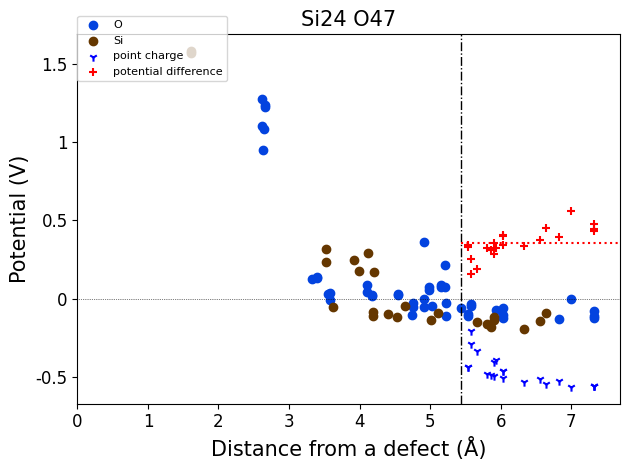

In [9]:
from defermi.corrections.kumagai import get_kumagai_correction, get_kumagai_correction_from_structures

defect_path = '../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_O/q2/1-PBE-SCF'
bulk_path = '../defermi/tests/test_files/SiO2-defects/Bulk-2x2x2-supercell'

corr, ax = get_kumagai_correction(
                                defect_path=defect_path,
                                bulk_path=bulk_path,
                                charge=2,
                                dielectric_tensor=3.9,  # we can also pass a constant or a 3x1 array - it is converted to a diagonal tensor
                                get_plot=True)

If you have simulation results from another DFT code, you can connect the site potentials to the `Structure` object by setting the the `properties` attribute for each `Site` object.

In [14]:
from defermi.corrections.kumagai import _get_structure_with_pot_pmg

structure = _get_structure_with_pot_pmg(defect_path)

for site in structure:
    print(site.properties) # set it manually for each site if you don't use VASP

{'potential': 86.386}
{'potential': 88.0658}
{'potential': 86.341}
{'potential': 86.3869}
{'potential': 86.3199}
{'potential': 86.7722}
{'potential': 86.3022}
{'potential': 86.3953}
{'potential': 88.0549}
{'potential': 86.3426}
{'potential': 86.3719}
{'potential': 86.2891}
{'potential': 86.7971}
{'potential': 86.3447}
{'potential': 86.434}
{'potential': 86.3876}
{'potential': 86.4281}
{'potential': 86.6581}
{'potential': 86.7154}
{'potential': 86.7306}
{'potential': 86.6499}
{'potential': 86.3644}
{'potential': 86.3323}
{'potential': 86.3659}
{'potential': 72.3537}
{'potential': 72.3643}
{'potential': 72.2952}
{'potential': 72.7778}
{'potential': 72.305}
{'potential': 72.4127}
{'potential': 72.3356}
{'potential': 72.4565}
{'potential': 73.6553}
{'potential': 72.3061}
{'potential': 72.4426}
{'potential': 72.2938}
{'potential': 72.5022}
{'potential': 72.3627}
{'potential': 72.4511}
{'potential': 73.6431}
{'potential': 72.5027}
{'potential': 72.4048}
{'potential': 72.3903}
{'potential': 7